# 🎬 유튜브 쇼츠 조회수와 원본 영상 조회수의 관계 분석

---

## 0️⃣ 주제 정하기

- **분야**: 콘텐츠/미디어 — 유튜브 쇼츠와 원본 영상의 조회수 관계
- **대상 채널**: `@helloiamwoninicetomeetyou` (채널명: 안녕하세요원이입니다잘부탁드립니다)
- **선정 이유**: 쇼츠는 대부분 원본(롱폼) 영상의 하이라이트를 편집해 만든 콘텐츠인데, 쇼츠가 많이 보였다고 해서 원본까지 유입으로 이어지는지 궁금해 선정. 정식 제출 과제가 아닌 웹 스크래핑 실전 연습(정적/동적 페이지 구분, robots.txt 확인, 텍스트 파싱 디버깅)을 목적으로 진행함



## 1️⃣ 분석 질문 정하기

- **메인 질문**: 쇼츠 조회수가 높으면 그 원본 영상의 조회수도 높을까?
- **세부 질문**
  - Q1. 쇼츠 평균 조회수와 원본 영상 조회수는 상관관계가 있는가?
  - Q2. 개별 쇼츠 단위로 봤을 때도 같은 경향이 나타나는가? (원본 1개 : 쇼츠 여러 개 구조 고려)
  - Q3. 한 원본에서 쇼츠를 많이 만들수록 원본 조회수도 높아지는가?
- **필요 컬럼**: 쇼츠 제목, 쇼츠 조회수, 원본 영상 ID, 원본 영상 제목, 원본 영상 조회수



## 2️⃣ 수집 대상 선정

- **대상 URL**
  - 쇼츠 목록: `https://www.youtube.com/@helloiamwoninicetomeetyou/shorts`
  - 개별 쇼츠 페이지: `https://www.youtube.com/shorts/{영상ID}`
  - 일반 동영상 목록: `https://www.youtube.com/@helloiamwoninicetomeetyou/videos`
- **수집 항목**: 쇼츠 제목·조회수, 원본 영상 ID·제목·조회수
- **윤리·법 확인**
  - robots.txt 확인 결과, 유튜브는 `/results`(검색), `/comment`, `/login` 등 특정 경로만 차단하며 채널 페이지·개별 영상 페이지는 차단 목록에 없어 수집 가능한 범위로 판단
  - 로그인 불필요, 개인정보 미포함
  - 공개적으로 노출된 채널의 공개 콘텐츠(제목, 조회수)만 수집, 댓글·비공개 정보는 수집하지 않음



## 3️⃣ 데이터 수집 및 저장

- **1단계 — 쇼츠 목록 수집**: `requests`로 쇼츠 탭 페이지 요청 → 페이지 내 JSON 텍스트(`accessibilityText`)에서 정규식으로 쇼츠 제목·조회수·영상ID 48개 추출 (스크롤 시 추가 로딩되는 나머지는 자바스크립트 트리거 실패로 미수집, 48개로 진행)
- **2단계 — 원본 영상 연결**: 48개 쇼츠 각각의 개별 페이지에 접속해 `reelCarouselButtonViewModel` 패턴을 탐색, 원본 영상 ID·제목 추출 (10개는 원본 없이 쇼츠 단독 콘텐츠로 확인되어 제외 → 38개, 고유 원본 영상 12개)
- **3단계 — 원본 조회수 수집**: 일반 동영상 목록 페이지에서 `lockupMetadataViewModel` 블록 단위로 제목·조회수 23개 추출 후, 원본제목 기준으로 매칭
- **CSV 저장**: `shorts_vs_original.csv`(38개, 쇼츠-원본 매칭), `shorts_grouped_by_original.csv`(12개, 원본 단위 그룹화)



## 4️⃣ 데이터 정제

- **정적/동적 페이지 판별**: 쇼츠 탭·개별 쇼츠 페이지·동영상 목록 페이지 모두 `requests`만으로 필요한 텍스트가 포함되어 있음을 확인 (`"거제 불주먹" in res.text` 등으로 검증) → Selenium 없이 `requests`+정규식만으로 수집
- **원본 없는 쇼츠 제외**: 48개 중 10개는 원본 영상 링크가 없는 쇼츠 단독 콘텐츠로, 비교 대상이 없어 분석에서 제외 (48 → 38)
- **N:1 구조 인지**: 원본 영상 하나에서 여러 개의 쇼츠가 파생되는 구조(고유 원본 12개, 쇼츠 38개)임을 확인하고, 개별 쇼츠 단위 분석과 원본 단위(평균) 분석을 모두 진행
- **자료형 변환**: 조회수 텍스트(`"99만"`, `"328만"` 등)를 숫자로 변환하는 함수 작성 (`만` → ×10,000, `억` → ×100,000,000 처리, 실제 데이터에는 `억` 단위 없음을 확인)
- **결측치 확인**: 쇼츠-원본 병합 후 결측치 0건 (38개 전부 매칭 완료)

### 최종 데이터 컬럼 설명

| 컬럼명 | 설명 |
|---|---|
| `쇼츠ID` | 쇼츠 영상 고유 ID |
| `쇼츠제목` | 쇼츠 영상 제목 |
| `쇼츠조회수_숫자` | 쇼츠 조회수 (숫자 변환 완료) |
| `원본ID` | 이 쇼츠가 파생된 원본 영상 ID |
| `원본제목` | 원본 영상 제목 |
| `원본조회수_숫자` | 원본 영상 조회수 (숫자 변환 완료) |

(그룹화 데이터 `grouped`는 `원본제목` 기준으로 `쇼츠평균조회수`, `쇼츠개수`, `원본조회수`를 집계한 12행 데이터)



## 5️⃣ 시각화로 살펴보기

- **Q1. 원본 단위 — 쇼츠 평균 조회수 vs 원본 조회수 (산점도 + 추세선)**
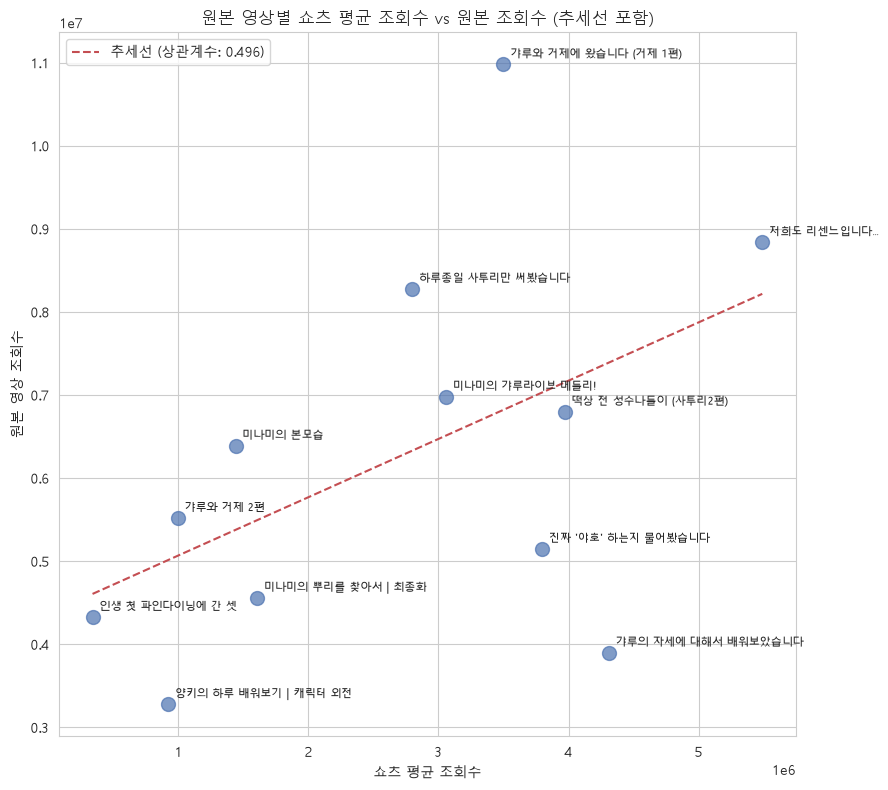
  - 상관계수 0.496으로 중간 정도의 양의 상관관계
  - 쇼츠 조회수가 높은 원본일수록 원본 조회수도 대체로 높아지는 경향은 있으나, 관계가 아주 강하지는 않음
  - "갸루의 자세에 대해서 배워보았습니다"는 쇼츠 평균 조회수는 높은(약 430만) 반면 원본 조회수는 상대적으로 낮아(약 390만) 예외적 사례로 확인됨

---

- **Q2. 개별 쇼츠 단위 — 쇼츠 조회수 vs 원본 조회수 (원본별 색상 구분, 38개)**
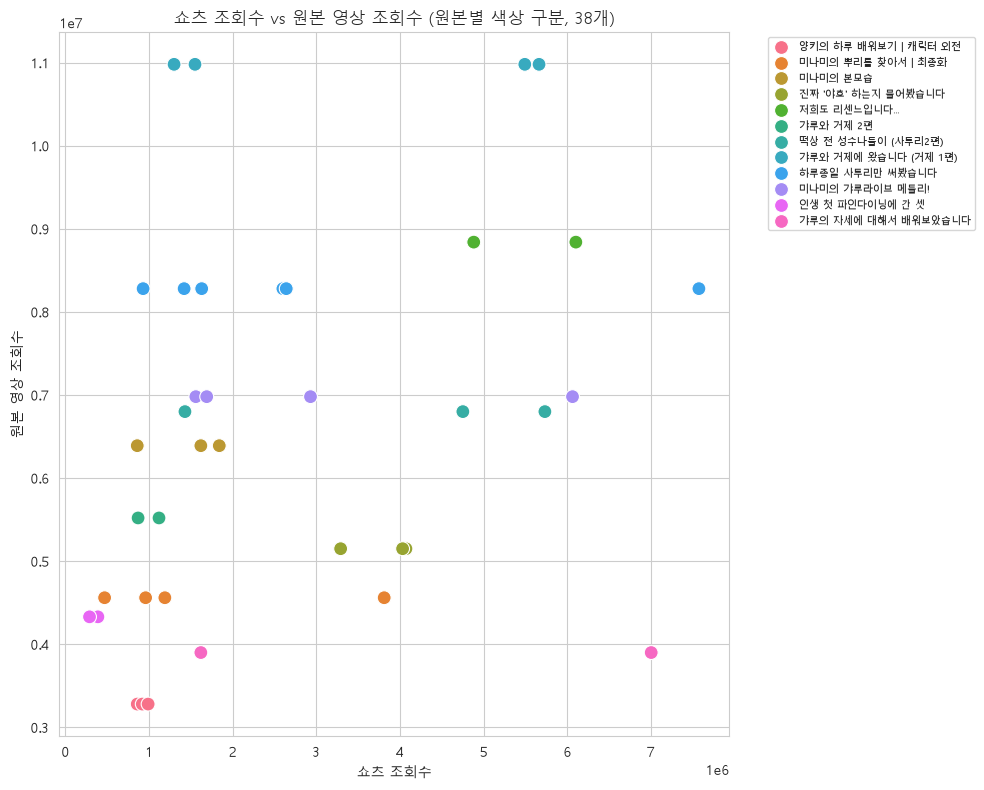
  - 같은 원본에서 나온 쇼츠들은 원본 조회수(y값)가 동일해 수평선을 이루는 구조가 뚜렷하게 나타남
  - 쇼츠 조회수가 높은 그룹(파란색·초록색 계열)이 원본 조회수도 높은 편으로 나타나 어느 정도 관계를 재확인
  - 개별 쇼츠 중 조회수 700만짜리(가루의 자세에 대해)가 있었음에도 해당 원본 조회수는 390만에 그쳐, 쇼츠 하나의 인기가 항상 원본 유입으로 이어지지는 않음을 보여줌

---

- **Q3. 쇼츠 개수 vs 원본 조회수 (산점도 + 추세선)**
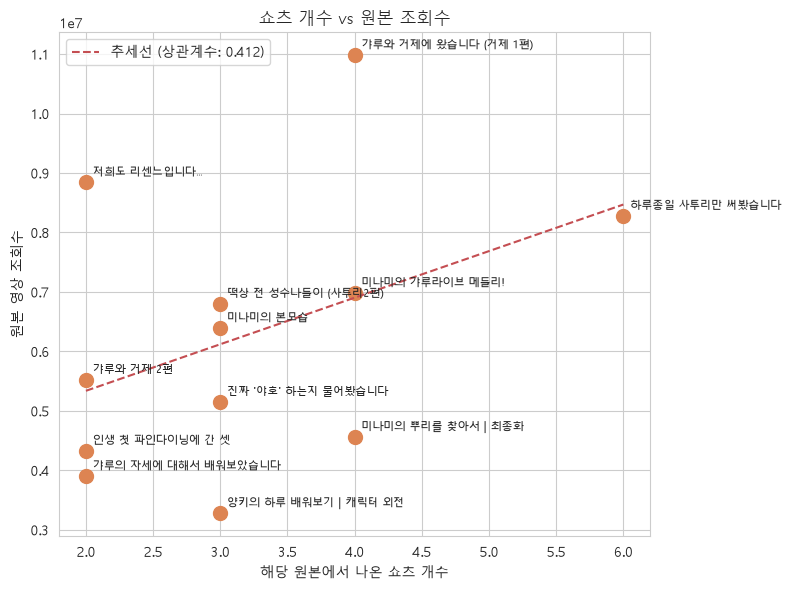
  - 상관계수 0.412로 약~중간 정도의 양의 상관관계
  - 한 원본에서 쇼츠를 많이 만들수록 원본 조회수도 다소 높아지는 경향은 있으나, Q1의 상관계수(0.496)보다는 관계가 약함
  - 즉 "쇼츠를 몇 개 만들었는가"보다는 "쇼츠 조회수 자체가 얼마나 높았는가"가 원본 조회수와 조금 더 관련 있어 보임



## 6️⃣ 마무리 정리

- **처음 질문**: 쇼츠 조회수가 높으면 원본 영상 조회수도 높을까?
- **알게 된 점**
  - 쇼츠 평균 조회수와 원본 조회수 사이에는 중간 정도의 양의 상관관계(0.496)가 확인됨 — 어느 정도는 "쇼츠가 잘되면 원본도 잘된다"는 경향이 있음
  - 다만 관계가 강하지 않아, 쇼츠 조회수만으로 원본 성과를 예측하기는 어려움
  - 쇼츠 개수(파생 콘텐츠 수)와 원본 조회수의 관계(0.412)는 조회수 자체와의 관계(0.496)보다 약해, 단순히 쇼츠를 많이 만드는 것보다 쇼츠 자체의 인기가 더 중요한 요인으로 보임
  - "가루의 자세에 대해서 배워보았습니다"처럼 쇼츠는 잘됐지만 원본은 상대적으로 덜 본 예외 사례가 존재해, 쇼츠의 바이럴이 항상 원본 시청으로 전환되지는 않음을 확인
- **한계**
  - 쇼츠 목록을 스크롤 자동화로 전량 수집하지 못해 48개(전체 93개 중 절반가량)로 분석 범위가 제한됨
  - 원본 영상 12개는 통계적으로 표본이 적어, 상관계수가 일부 예외 사례에 민감하게 흔들릴 수 있음
  - 조회수는 특정 시점의 스냅샷이라, 쇼츠와 원본의 게시 시점 차이(원본이 먼저 나오고 쇼츠가 나중에 파생되는 시차)를 고려하지 못함
- **후속 질문**
  - 스크롤 자동화(Selenium)로 채널의 쇼츠 93개를 전량 수집하면 상관관계가 더 명확해지는지 확인
  - 원본 영상 게시일과 쇼츠 게시일의 시차를 반영하면, "쇼츠가 원본 조회수를 실제로 끌어올리는 효과"를 더 정확히 볼 수 있는지 확인
  - 좋아요 수·댓글 수 등 다른 지표까지 포함하면 쇼츠-원본 관계를 더 다각도로 설명할 수 있는지 확인